# 1 CARGADO DE LIBRERIAS

In [ ]:
# Librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime
import joblib
import pickle

# Visualización y reducción de dimensionalidad
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Preprocesamiento y partición de datos
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Modelos
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Manejo de desbalance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

# Utilidades Colab (opcional)
from google.colab import files


# 2 RECOLECCION DE DATOS Y CARGA DEL DATA SET

In [ ]:
archivo = files.upload()

Saving 2006-2025 examenes de ingreso.xlsx to 2006-2025 examenes de ingreso.xlsx


In [ ]:
df_postulantes = pd.read_excel("2006-2025 examenes de ingreso.xlsx")

print("Dataset de postulantes:")
display(df_postulantes.head())


Dataset de postulantes:


,ANIO,PERIODO,DESCRIPCIÓN,OPC_INGRESO,COD_PLAN,NOMBRE_PLAN,FECHA_NAC,SEXO,ESTADO_CIVIL,COD_NACIONALIDAD,...,MUNICIPIO,TRABAJA,ANIO_BACHILLERATO,NOMBRE_COLEGIO,PROVINCIA_COLEGIO,CIUDAD_COLEGIO,COD_TIPO_COL,TIPO_COLEGIO,PROM_FINAL,RESULTADO_FINAL
0,2006,2,EXAMEN DE INGRESO,1,309801,LICENCIATURA EN INGENIERIA INDUSTRIAL,1987-03-25 00:00:00,MASCULINO,SOLTERO(A),BO,...,NaN,NO,0,FRANCISCO VIGNAUD,COCHABAMBA (CERCADO),COCHABAMBA,2,FISCAL URBANO,NaN,ABA
1,2006,2,EXAMEN DE INGRESO,1,429701,LICENCIATURA EN INGENIERIA ELECTRONICA,1985-09-06 00:00:00,MASCULINO,SOLTERO(A),BO,...,NaN,NO,0,MEJILLONES,COCHABAMBA (CERCADO),COCHABAMBA,2,FISCAL URBANO,21.0,REP
2,2006,2,EXAMEN DE INGRESO,1,419701,LICENCIATURA EN INGENIERIA DE SISTEMAS,1987-05-24 00:00:00,MASCULINO,SOLTERO(A),BO,...,NaN,NO,0,INCOS,ANTONIO VACA DIEZ,BENI,2,FISCAL URBANO,31.0,REP
3,2006,2,EXAMEN DE INGRESO,1,429701,LICENCIATURA EN INGENIERIA ELECTRONICA,1984-12-22 00:00:00,MASCULINO,SOLTERO(A),BO,...,NaN,NO,0,FE Y ALEGRIA,COCHABAMBA (CERCADO),COCHABAMBA,2,FISCAL URBANO,11.0,REP
4,2006,2,EXAMEN DE INGRESO,1,309801,LICENCIATURA EN INGENIERIA INDUSTRIAL,1985-02-19 00:00:00,MASCULINO,SOLTERO(A),BO,...,NaN,NO,0,NORDICO BOLIVIANO,COCHABAMBA (CERCADO),COCHABAMBA,2,FISCAL URBANO,21.0,REP


# 3 DESCRIPCION GENERAL DEL DATA SET

## Cantidad de filas y columnas del data set

In [ ]:
df_postulantes.shape

(98009, 26)

## Colunas existentes en el data set

In [ ]:
df_postulantes.columns

Index(['ANIO', 'PERIODO', 'DESCRIPCIÓN', 'OPC_INGRESO', 'COD_PLAN',
       'NOMBRE_PLAN', 'FECHA_NAC', 'SEXO', 'ESTADO_CIVIL', 'COD_NACIONALIDAD',
       'NACIONALIDAD', 'ID_CIUDAD', 'CIUDAD_NACIMIENTO', 'ID_PROVINCIA',
       'PROVINCIA_NACIMIENTO', 'COD MUNICIPIO', 'MUNICIPIO', 'TRABAJA',
       'ANIO_BACHILLERATO', 'NOMBRE_COLEGIO', 'PROVINCIA_COLEGIO',
       'CIUDAD_COLEGIO', 'COD_TIPO_COL', 'TIPO_COLEGIO', 'PROM_FINAL',
       'RESULTADO_FINAL'],
      dtype='object')

## Tipo de datos de las variables

In [ ]:
df_postulantes.dtypes

,0
ANIO,int64
PERIODO,int64
DESCRIPCIÓN,object
OPC_INGRESO,int64
COD_PLAN,int64
NOMBRE_PLAN,object
FECHA_NAC,object
SEXO,object
ESTADO_CIVIL,object
COD_NACIONALIDAD,object


## Cantidad de datos por columna

In [ ]:
df_postulantes.count()

,0
ANIO,98009
PERIODO,98009
DESCRIPCIÓN,98009
OPC_INGRESO,98009
COD_PLAN,98009
NOMBRE_PLAN,98009
FECHA_NAC,98009
SEXO,98009
ESTADO_CIVIL,98009
COD_NACIONALIDAD,98009


## Descripcion general de los datos

In [ ]:
df_postulantes.describe()

,ANIO,PERIODO,OPC_INGRESO,COD_PLAN,ID_CIUDAD,ID_PROVINCIA,COD MUNICIPIO,ANIO_BACHILLERATO,COD_TIPO_COL,PROM_FINAL
count,98009.000000,98009.000000,98009.000000,98009.000000,98009.000000,98009.000000,49968.000000,98009.000000,98009.000000,96639.000000
mean,2016.729668,1.257405,1.622902,381919.105929,3.203563,2.461794,1.315482,1970.959269,1.807436,38.913151
std,4.882355,0.437207,0.698014,119913.395600,1.064754,3.043637,0.961886,295.287516,0.394315,15.598067
min,2006.000000,1.000000,1.000000,114071.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2013.000000,1.000000,1.000000,319801.000000,3.000000,1.000000,1.000000,2011.000000,2.000000,26.000000
50%,2017.000000,1.000000,1.000000,339701.000000,3.000000,1.000000,1.000000,2016.000000,2.000000,36.000000
75%,2020.000000,2.000000,2.000000,419701.000000,3.000000,2.000000,1.000000,2019.000000,2.000000,47.000000
max,2025.000000,2.000000,3.000000,760101.000000,9.000000,19.000000,8.000000,2024.000000,2.000000,100.000000


In [ ]:
df_postulantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98009 entries, 0 to 98008
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ANIO                  98009 non-null  int64  
 1   PERIODO               98009 non-null  int64  
 2   DESCRIPCIÓN           98009 non-null  object 
 3   OPC_INGRESO           98009 non-null  int64  
 4   COD_PLAN              98009 non-null  int64  
 5   NOMBRE_PLAN           98009 non-null  object 
 6   FECHA_NAC             98009 non-null  object 
 7   SEXO                  98009 non-null  object 
 8   ESTADO_CIVIL          98009 non-null  object 
 9   COD_NACIONALIDAD      98009 non-null  object 
 10  NACIONALIDAD          98009 non-null  object 
 11  ID_CIUDAD             98009 non-null  int64  
 12  CIUDAD_NACIMIENTO     98009 non-null  object 
 13  ID_PROVINCIA          98009 non-null  int64  
 14  PROVINCIA_NACIMIENTO  98009 non-null  object 
 15  COD MUNICIPIO      

## Cantidad de valores nulos por columna

In [ ]:
print(df_postulantes.isna().sum())

ANIO                        0
PERIODO                     0
DESCRIPCIÓN                 0
OPC_INGRESO                 0
COD_PLAN                    0
NOMBRE_PLAN                 0
FECHA_NAC                   0
SEXO                        0
ESTADO_CIVIL                0
COD_NACIONALIDAD            0
NACIONALIDAD                0
ID_CIUDAD                   0
CIUDAD_NACIMIENTO           0
ID_PROVINCIA                0
PROVINCIA_NACIMIENTO        0
COD MUNICIPIO           48041
MUNICIPIO               48041
TRABAJA                     0
ANIO_BACHILLERATO           0
NOMBRE_COLEGIO              0
PROVINCIA_COLEGIO           0
CIUDAD_COLEGIO              0
COD_TIPO_COL                0
TIPO_COLEGIO                0
PROM_FINAL               1370
RESULTADO_FINAL             0
dtype: int64


## Porcentaje de valores nulos por columna

In [ ]:
print((df_postulantes.isna().mean() * 100).round(2))

total_nulos = df_postulantes.isna().sum().sum()
total_celdas = df_postulantes.size
porcentaje_total_nulos = (total_nulos / total_celdas) * 100

print("\n Total de valores nulos en el dataset:", total_nulos)
print(f" Porcentaje total de nulos: {porcentaje_total_nulos:.2f}%")

ANIO                     0.00
PERIODO                  0.00
DESCRIPCIÓN              0.00
OPC_INGRESO              0.00
COD_PLAN                 0.00
NOMBRE_PLAN              0.00
FECHA_NAC                0.00
SEXO                     0.00
ESTADO_CIVIL             0.00
COD_NACIONALIDAD         0.00
NACIONALIDAD             0.00
ID_CIUDAD                0.00
CIUDAD_NACIMIENTO        0.00
ID_PROVINCIA             0.00
PROVINCIA_NACIMIENTO     0.00
COD MUNICIPIO           49.02
MUNICIPIO               49.02
TRABAJA                  0.00
ANIO_BACHILLERATO        0.00
NOMBRE_COLEGIO           0.00
PROVINCIA_COLEGIO        0.00
CIUDAD_COLEGIO           0.00
COD_TIPO_COL             0.00
TIPO_COLEGIO             0.00
PROM_FINAL               1.40
RESULTADO_FINAL          0.00
dtype: float64

 Total de valores nulos en el dataset: 97452
 Porcentaje total de nulos: 3.82%


## Cantidad de duplicados

In [ ]:
duplicados = df_postulantes.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)


Cantidad de filas duplicadas: 5


In [ ]:
print("Total de filas:", df_postulantes.shape[0])
print("Filas únicas:", df_postulantes.drop_duplicates().shape[0])


Total de filas: 98009
Filas únicas: 98004


# 4 PREPARACION DEL CONJUNTO DE DATOS

## Creacion de Variables

### Transformacion del tipo de datos de FECHA_NAC de date a datetime

In [ ]:
df_postulantes['FECHA_NAC'] =pd.to_datetime(df_postulantes['FECHA_NAC'],errors='coerce', dayfirst=True)

### Columna EDAD

Agregamos la columna EDAD que se obtiene de la diferencia entre año que dio el examen y su fecha nacimiento

In [ ]:

df_postulantes['EDAD'] = df_postulantes.apply(
    lambda fila: fila['ANIO'] - fila['FECHA_NAC'].year
    - ((1, 1) < (fila['FECHA_NAC'].month, fila['FECHA_NAC'].day)), axis=1)


Convertimos la columna EDAD creada a int

In [ ]:
df_postulantes['EDAD'] = df_postulantes['EDAD'].fillna(0)

df_postulantes['EDAD'] = df_postulantes['EDAD'].astype(int)

In [ ]:
Observacion de los valores que consideran como outliers en la columna EDAD

In [ ]:
outliers_edad = df_postulantes[
    (df_postulantes['EDAD'].isin([0, 8])) |
    (df_postulantes['EDAD'] >= 41)
]

print(outliers_edad)


       ANIO  PERIODO                DESCRIPCIÓN  OPC_INGRESO  COD_PLAN  \
1780   2007        1   PRIMER EXAMEN DE INGRESO            1    419701   
2868   2007        1  SEGUNDO EXAMEN DE INGRESO            2    419701   
15720  2011        1  SEGUNDO EXAMEN DE INGRESO            2    429701   
22791  2013        1   PRIMER EXAMEN DE INGRESO            1    429701   
23111  2013        1   PRIMER EXAMEN DE INGRESO            1    319801   
23253  2013        1   PRIMER EXAMEN DE INGRESO            1    339701   
25329  2013        2          EXAMEN DE INGRESO            1    309801   
25515  2013        2          EXAMEN DE INGRESO            1    419701   
25719  2013        2          EXAMEN DE INGRESO            1    339701   
26804  2014        1   PRIMER EXAMEN DE INGRESO            1    309801   
28224  2014        1  SEGUNDO EXAMEN DE INGRESO            2    419701   
29280  2014        1  SEGUNDO EXAMEN DE INGRESO            2    339701   
32935  2015        1  SEGUNDO EXAMEN D

Cantidad de estudiantes por edad

In [ ]:
alumnos_por_edad = df_postulantes.groupby('EDAD').size().reset_index(name='Cantidad')
print(alumnos_por_edad)


    EDAD  Cantidad
0      0         2
1      8         2
2     14         8
3     15        53
4     16      1944
5     17     27937
6     18     33163
7     19     16430
8     20      8276
9     21      4287
10    22      2343
11    23      1334
12    24       758
13    25       441
14    26       263
15    27       202
16    28       124
17    29       107
18    30        79
19    31        52
20    32        35
21    33        19
22    34        35
23    35        24
24    36        12
25    37        12
26    38        21
27    39         5
28    40        14
29    41         4
30    42         4
31    43         4
32    44         1
33    45         3
34    46         1
35    47         1
36    48         1
37    50         2
38    54         1
39    55         2
40    68         2
41    70         1


In [ ]:
df_postulantes['EDAD'] = df_postulantes.apply(
    lambda fila: fila['ANIO'] - fila['FECHA_NAC'].year
    - ((1, 1) < (fila['FECHA_NAC'].month, fila['FECHA_NAC'].day)),
    axis=1
)
print("Edades calculadas en df_data:")
print(df_postulantes[['ANIO', 'FECHA_NAC', 'EDAD']].head())

Edades calculadas en df_data:
   ANIO  FECHA_NAC  EDAD
0  2006 1987-03-25  18.0
1  2006 1985-09-06  20.0
2  2006 1987-05-24  18.0
3  2006 1984-12-22  21.0
4  2006 1985-02-19  20.0


### Columna ANIOS_POST_BACH

Son lo años que pasaron entre el bachillerato y el examen de ingreso de los postulantes

In [ ]:
df_postulantes["ANIOS_POST_BACH"] = (
    df_postulantes["ANIO"] - df_postulantes["ANIO_BACHILLERATO"]
).where(df_postulantes["ANIO_BACHILLERATO"] != 0, 0)

df_postulantes["ANIOS_POST_BACH"] = df_postulantes["ANIOS_POST_BACH"].astype(int)


print(df_postulantes[['ANIOS_POST_BACH']].head())

   ANIOS_POST_BACH
0                0
1                0
2                0
3                0
4                0


### Columna TRABAJO_COLEGIO

Una combinación del estado laboral del postulante y el tipo de colegio de procedencia

In [ ]:
df_postulantes["TRABAJO_COLEGIO"] = (
    df_postulantes["TRABAJA"].astype(str) + "_" + df_postulantes["TIPO_COLEGIO"].astype(str)
)

print(df_postulantes[['TRABAJO_COLEGIO']].head())

    TRABAJO_COLEGIO
0  NO_FISCAL URBANO
1  NO_FISCAL URBANO
2  NO_FISCAL URBANO
3  NO_FISCAL URBANO
4  NO_FISCAL URBANO


### Columna MIGRA_UNIVERSIDAD

Son los estudiantes que migraron a la cuidad y provicia de la universidad

In [ ]:
df_postulantes["MIGRA_UNIVERSIDAD"] = (
    (df_postulantes["CIUDAD_COLEGIO"] != "COCHABAMBA") |
    (df_postulantes["PROVINCIA_COLEGIO"] != "COCHABAMBA (CERCADO)")
).astype(int)

print(df_postulantes[['MIGRA_UNIVERSIDAD']].head())

   MIGRA_UNIVERSIDAD
0                  0
1                  0
2                  1
3                  0
4                  0


### Columna MAYOR_EDAD

Estudiantes si son mayores de edad

In [ ]:
df_postulantes["MAYOR_EDAD"] = (df_postulantes["EDAD"] >= 18).astype(int)

print(df_postulantes[['MAYOR_EDAD']].head())

   MAYOR_EDAD
0           1
1           1
2           1
3           1
4           1


### Columna TASA_APR_COLEGIO

Muestra la tasa de aprobacion de los colegios

In [ ]:
tasa_col = (
    df_postulantes.groupby("NOMBRE_COLEGIO")["RESULTADO_FINAL"]
      .apply(lambda x: (x == "APR").mean())
)

df_postulantes["TASA_APR_COLEGIO"] = df_postulantes["NOMBRE_COLEGIO"].map(tasa_col)
print(df_postulantes[['TASA_APR_COLEGIO']].head())


   TASA_APR_COLEGIO
0          0.203390
1          0.120690
2          0.205882
3          0.109091
4          0.188755


## Estado final de los datos antes del modelo

In [ ]:
df_postulantes.head()

,ANIO,PERIODO,DESCRIPCIÓN,OPC_INGRESO,COD_PLAN,NOMBRE_PLAN,FECHA_NAC,SEXO,ESTADO_CIVIL,COD_NACIONALIDAD,...,COD_TIPO_COL,TIPO_COLEGIO,PROM_FINAL,RESULTADO_FINAL,EDAD,ANIOS_POST_BACH,TRABAJO_COLEGIO,MIGRA_UNIVERSIDAD,MAYOR_EDAD,TASA_APR_COLEGIO
0,2006,2,EXAMEN DE INGRESO,1,309801,LICENCIATURA EN INGENIERIA INDUSTRIAL,1987-03-25,MASCULINO,SOLTERO(A),BO,...,2,FISCAL URBANO,NaN,ABA,18,0,NO_FISCAL URBANO,0,1,0.203390
1,2006,2,EXAMEN DE INGRESO,1,429701,LICENCIATURA EN INGENIERIA ELECTRONICA,1985-09-06,MASCULINO,SOLTERO(A),BO,...,2,FISCAL URBANO,21.0,REP,20,0,NO_FISCAL URBANO,0,1,0.120690
2,2006,2,EXAMEN DE INGRESO,1,419701,LICENCIATURA EN INGENIERIA DE SISTEMAS,1987-05-24,MASCULINO,SOLTERO(A),BO,...,2,FISCAL URBANO,31.0,REP,18,0,NO_FISCAL URBANO,1,1,0.205882
3,2006,2,EXAMEN DE INGRESO,1,429701,LICENCIATURA EN INGENIERIA ELECTRONICA,1984-12-22,MASCULINO,SOLTERO(A),BO,...,2,FISCAL URBANO,11.0,REP,21,0,NO_FISCAL URBANO,0,1,0.109091
4,2006,2,EXAMEN DE INGRESO,1,309801,LICENCIATURA EN INGENIERIA INDUSTRIAL,1985-02-19,MASCULINO,SOLTERO(A),BO,...,2,FISCAL URBANO,21.0,REP,20,0,NO_FISCAL URBANO,0,1,0.188755


In [ ]:
df_postulantes.columns


Index(['ANIO', 'PERIODO', 'DESCRIPCIÓN', 'OPC_INGRESO', 'COD_PLAN',
       'NOMBRE_PLAN', 'FECHA_NAC', 'SEXO', 'ESTADO_CIVIL', 'COD_NACIONALIDAD',
       'NACIONALIDAD', 'ID_CIUDAD', 'CIUDAD_NACIMIENTO', 'ID_PROVINCIA',
       'PROVINCIA_NACIMIENTO', 'COD MUNICIPIO', 'MUNICIPIO', 'TRABAJA',
       'ANIO_BACHILLERATO', 'NOMBRE_COLEGIO', 'PROVINCIA_COLEGIO',
       'CIUDAD_COLEGIO', 'COD_TIPO_COL', 'TIPO_COLEGIO', 'PROM_FINAL',
       'RESULTADO_FINAL', 'EDAD', 'ANIOS_POST_BACH', 'TRABAJO_COLEGIO',
       'MIGRA_UNIVERSIDAD', 'MAYOR_EDAD', 'TASA_APR_COLEGIO'],
      dtype='object')

In [ ]:
# Este es primero para subir a Power BIA
df_postulantes.to_excel("postulantes_fcyt.xlsx", index=False)
# Este otro es para la interfaz
df_postulantes.to_csv("dataset_eda.csv", index=False)


#5 ANALISIS EXPLORATORIO DE DATOS

## Estadistica descriptiva de las variables PROM_FINAL, EDAD y ANIOS_POST_BACH

In [ ]:
df_postulantes[['PROM_FINAL', 'EDAD', 'ANIOS_POST_BACH']].describe()

In [ ]:
medias = df_postulantes[['PROM_FINAL', 'EDAD', 'ANIOS_POST_BACH']].mean()

plt.figure()
medias.plot(kind='bar')
plt.ylabel('Valor promedio')
plt.title('Promedio de las variables numéricas analizadas')
plt.xticks(rotation=0)
plt.show()



In [ ]:
plt.figure()
plt.boxplot([
    df_postulantes['PROM_FINAL'].dropna(),
    df_postulantes['EDAD'].dropna(),
    df_postulantes['ANIOS_POST_BACH'].dropna()
], labels=['PROM_FINAL', 'EDAD', 'ANIOS_POST_BACH'])
plt.ylabel('Valor')
plt.title('Resumen de la dispersión de variables numéricas')
plt.show()


## Histograma del puntaje final del examen

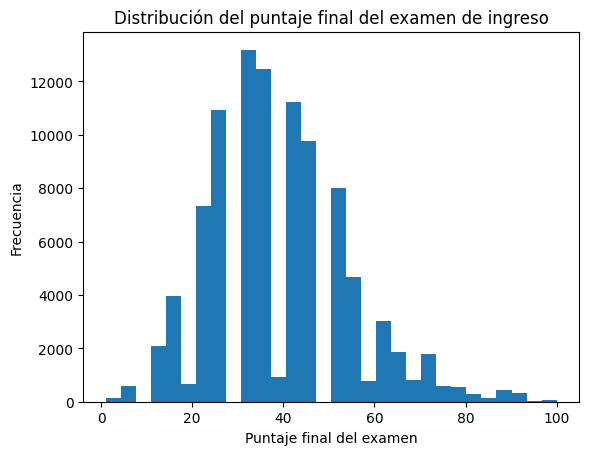

In [ ]:
plt.figure()
plt.hist(df_postulantes['PROM_FINAL'].dropna(), bins=30)
plt.xlabel('Puntaje final del examen')
plt.ylabel('Frecuencia')
plt.title('Distribución del puntaje final del examen de ingreso')
plt.show()


## Promedio de postulantes por ciudad de nacimiento

   CIUDAD_NACIMIENTO  PROM_FINAL
5  OTRA (EXTRANJERO)   40.979290
2         COCHABAMBA   39.156115
1         CHUQUISACA   38.950233
9             TARIJA   38.817803
4              ORURO   38.305237
3             LA PAZ   38.096464
6              PANDO   37.602410
8         SANTA CRUZ   37.362299
7             POTOSI   37.010353
0               BENI   36.242000


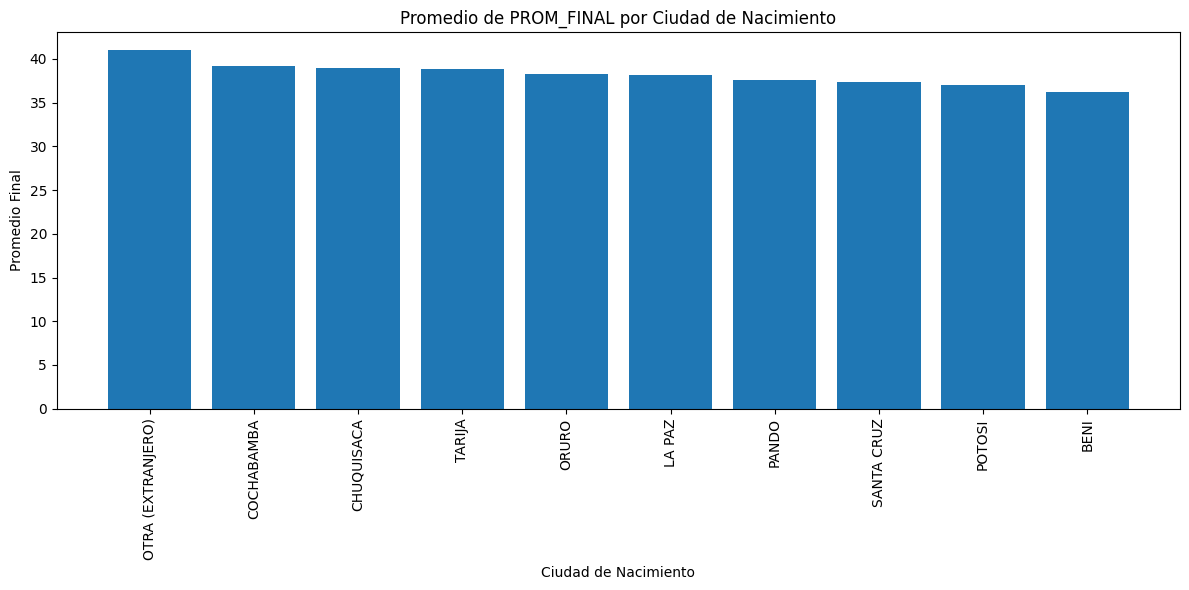

In [ ]:
df_promedio_ciudad = (
    df_postulantes.groupby("CIUDAD_NACIMIENTO")["PROM_FINAL"]
    .mean()
    .reset_index()
    .sort_values("PROM_FINAL", ascending=False)
)
print(df_promedio_ciudad)

plt.figure(figsize=(12,6))
plt.bar(df_promedio_ciudad["CIUDAD_NACIMIENTO"], df_promedio_ciudad["PROM_FINAL"])
plt.xticks(rotation=90)
plt.xlabel("Ciudad de Nacimiento")
plt.ylabel("Promedio Final")
plt.title("Promedio de PROM_FINAL por Ciudad de Nacimiento")
plt.tight_layout()
plt.show()


## Promedio de postulantes por tipo de colegio

---



         TIPO_COLEGIO  PROM_FINAL
7   PARTICULAR URBANO   41.573035
3     CONVENIO URBANO   41.437807
2      CONVENIO RURAL   39.339688
1  COMUNITARIA URBANO   39.106218
5       FISCAL URBANO   38.429733
6    PARTICULAR RURAL   38.111842
4        FISCAL RURAL   36.652463
0   COMUNITARIA RURAL   33.872642


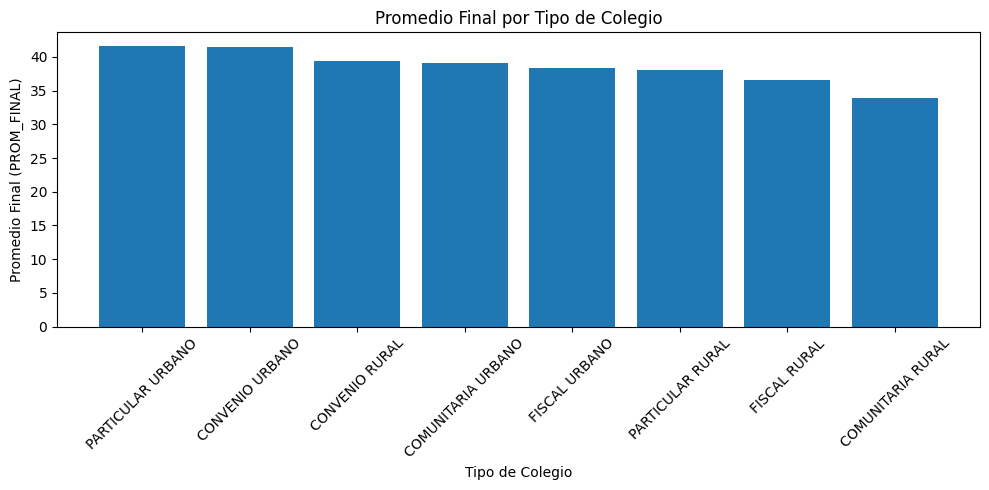

In [ ]:
df_prom_tipo = (
    df_postulantes.groupby("TIPO_COLEGIO")["PROM_FINAL"]
    .mean()
    .reset_index()
    .sort_values("PROM_FINAL", ascending=False)
)
print(df_prom_tipo)

plt.figure(figsize=(10,5))
plt.bar(df_prom_tipo["TIPO_COLEGIO"], df_prom_tipo["PROM_FINAL"])
plt.xlabel("Tipo de Colegio")
plt.ylabel("Promedio Final (PROM_FINAL)")
plt.title("Promedio Final por Tipo de Colegio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Promedio de postulantes por sexo y año

    ANIO       SEXO  PROM_FINAL
0   2006   FEMENINO   29.006135
1   2006  MASCULINO   30.565217
2   2007   FEMENINO   36.498512
3   2007  MASCULINO   34.792251
4   2008   FEMENINO   39.876812
5   2008  MASCULINO   41.074040
6   2009   FEMENINO   38.435897
7   2009  MASCULINO   35.945632
8   2010   FEMENINO   41.844347
9   2010  MASCULINO   39.983757
10  2011   FEMENINO   39.284379
11  2011  MASCULINO   38.284600
12  2012   FEMENINO   36.445050
13  2012  MASCULINO   34.698649
14  2013   FEMENINO   40.792648
15  2013  MASCULINO   39.036353
16  2014   FEMENINO   39.879111
17  2014  MASCULINO   37.794176
18  2015   FEMENINO   39.397989
19  2015  MASCULINO   39.073051
20  2016   FEMENINO   43.117586
21  2016  MASCULINO   41.100413
22  2017   FEMENINO   35.403812
23  2017  MASCULINO   33.961801
24  2018   FEMENINO   36.586897
25  2018  MASCULINO   36.606166
26  2019   FEMENINO   38.648594
27  2019  MASCULINO   37.013611
28  2020   FEMENINO   39.136917
29  2020  MASCULINO   38.390190
30  2021

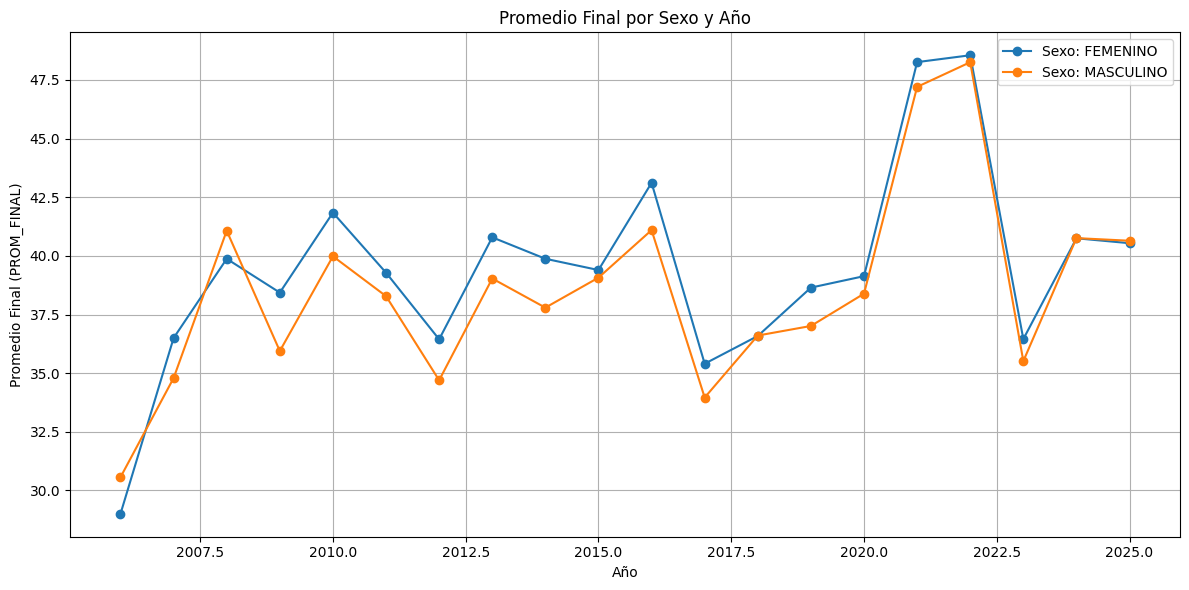

In [ ]:
df_prom_sexo_anio = (
    df_postulantes.groupby(["ANIO", "SEXO"])["PROM_FINAL"]
    .mean()
    .reset_index()
    .sort_values("ANIO")
)
print(df_prom_sexo_anio)

plt.figure(figsize=(12,6))

for sexo in df_prom_sexo_anio["SEXO"].unique():
    datos = df_prom_sexo_anio[df_prom_sexo_anio["SEXO"] == sexo]
    plt.plot(datos["ANIO"], datos["PROM_FINAL"], marker="o", label=f"Sexo: {sexo}")

plt.xlabel("Año")
plt.ylabel("Promedio Final (PROM_FINAL)")
plt.title("Promedio Final por Sexo y Año")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Cantidad de resprobados y aprobados por año


    ANIO RESULTADO_FINAL  CANTIDAD
0   2006             ABA         9
1   2006             APR       204
2   2006             REP       557
3   2007             ABA        15
4   2007             APR       679
5   2007             REP      2419
6   2008             ABA        45
7   2008             APR       796
8   2008             REP      2055
9   2009             ABA        27
10  2009             APR       694
11  2009             REP      2767
12  2010             ABA        33
13  2010             APR       839
14  2010             REP      2243
15  2011             ABA        32
16  2011             APR       771
17  2011             REP      2543
18  2012             ABA        46
19  2012             APR       745
20  2012             REP      3910
21  2013             ABA        34
22  2013             APR      1128
23  2013             REP      3289
24  2014             ABA        45
25  2014             APR      1037
26  2014             REP      3591
27  2015            

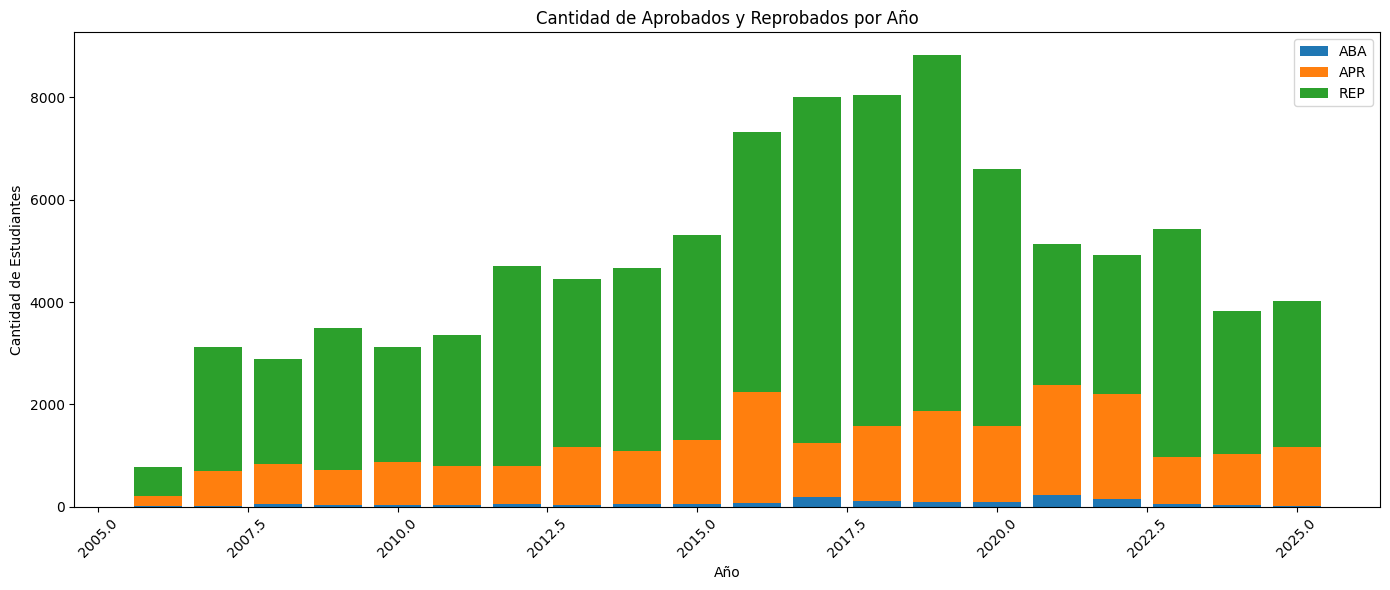

In [ ]:
df_resultados_anio = (
    df_postulantes
    .groupby(["ANIO", "RESULTADO_FINAL"])["RESULTADO_FINAL"]
    .count()
    .reset_index(name="CANTIDAD")
    .sort_values("ANIO")
)
print(df_resultados_anio)

# Pivot seguro
pivot_res = df_resultados_anio.pivot(index="ANIO", columns="RESULTADO_FINAL", values="CANTIDAD").fillna(0)

# Extraer columnas dinámicamente
columnas = pivot_res.columns.tolist()
print("Columnas en pivot:", columnas)

anios = pivot_res.index
plt.figure(figsize=(14,6))

bottom = np.zeros(len(anios))
for col in columnas:
    plt.bar(anios, pivot_res[col], bottom=bottom, label=col)
    bottom += pivot_res[col]

plt.xlabel("Año")
plt.ylabel("Cantidad de Estudiantes")
plt.title("Cantidad de Aprobados y Reprobados por Año")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#6 MODELOS PREDICTIVOS

## APLICACION DEL ALGORITMO XGBOOTS CON UNDERSAMPLING

Seleccion de variables para los modelos

In [ ]:
columnas_modelo = [
   "PERIODO",
    "SEXO",
    "EDAD",
    "OPC_INGRESO",
    "CIUDAD_COLEGIO",
    "PROVINCIA_COLEGIO",
    "ANIO_BACHILLERATO",
    "MUNICIPIO",
    "NACIONALIDAD",
    "ESTADO_CIVIL",
    "RESULTADO_FINAL",
    "ANIOS_POST_BACH",
    "TASA_APR_COLEGIO",
    "TRABAJO_COLEGIO",
    "MAYOR_EDAD",
    "MIGRA_UNIVERSIDAD",
]

Guardado de data set, para subir a la interfaz

In [ ]:
df_modelo = df_postulantes[columnas_modelo].copy()

Limitacion de los valores de la varible EDAD

In [ ]:
df_postulantes = df_modelo[
    (df_modelo["EDAD"] >= 15) &
    (df_modelo["EDAD"] <= 43)
]

Eliminacion de la columna EDAD

In [ ]:
df_modelo = df_modelo.drop(columns=["EDAD"])

Filtrar valores inválidos de ANIO_BACHILLERATO solo para el modelo

In [ ]:
df_modelo = df_modelo[df_modelo["ANIO_BACHILLERATO"] > 0]

Eliminacion de los valores nulos de la columna MUNICIPIO

In [ ]:
df_modelo = df_modelo.dropna(subset=['MUNICIPIO'])

Resetear índice del df_modelo

In [ ]:
df_modelo = df_modelo.reset_index(drop=True)

Filtrar clases válidas para la variable RESULTADO_FINAL

In [ ]:
df_modelo = df_modelo[df_modelo["RESULTADO_FINAL"].isin(["APR", "REP"])]

Mapeado de la variable objetivo RESULATDO_FINAL

In [ ]:
df_modelo["RESULTADO_FINAL"] = df_modelo["RESULTADO_FINAL"].map({
    "APR": 1,
    "REP": 0
})
print(df_modelo[['RESULTADO_FINAL']].head())

,0
PERIODO,0
SEXO,0
OPC_INGRESO,0
CIUDAD_COLEGIO,0
PROVINCIA_COLEGIO,0
ANIO_BACHILLERATO,0
MUNICIPIO,0
NACIONALIDAD,0
ESTADO_CIVIL,0
RESULTADO_FINAL,0


Verificacion de los valores nuelos por columna

In [ ]:
df_modelo.isna().sum()

Estado final del tabla minable

In [ ]:
df_modelo.columns
df_modelo.head()

Index(['PERIODO', 'SEXO', 'OPC_INGRESO', 'CIUDAD_COLEGIO', 'PROVINCIA_COLEGIO',
       'ANIO_BACHILLERATO', 'MUNICIPIO', 'NACIONALIDAD', 'ESTADO_CIVIL',
       'RESULTADO_FINAL', 'ANIOS_POST_BACH', 'TASA_APR_COLEGIO',
       'TRABAJO_COLEGIO', 'MAYOR_EDAD', 'MIGRA_UNIVERSIDAD'],
      dtype='object')

Guardado de la tabla minable para la documentacion

In [ ]:
df_modelo.to_csv("df_modelo_minable.csv", index=False)

Asignacion X e y para el modelo

In [ ]:
X = df_modelo.drop(columns=["RESULTADO_FINAL"])
y = df_modelo["RESULTADO_FINAL"]

Estado de la variable X

In [ ]:
X.head()

,PERIODO,SEXO,OPC_INGRESO,CIUDAD_COLEGIO,PROVINCIA_COLEGIO,ANIO_BACHILLERATO,MUNICIPIO,NACIONALIDAD,ESTADO_CIVIL,ANIOS_POST_BACH,TASA_APR_COLEGIO,TRABAJO_COLEGIO,MAYOR_EDAD,MIGRA_UNIVERSIDAD
0,2,MASCULINO,1,COCHABAMBA,COCHABAMBA (CERCADO),2005,COCHABAMBA,BOLIVIA,SOLTERO(A),1,0.271493,SI_FISCAL URBANO,0,0
1,2,FEMENINO,1,POTOSI,RAFAEL BUSTILLO,2003,LLALLAGUA,BOLIVIA,SOLTERO(A),3,0.259259,SI_FISCAL RURAL,1,1
2,1,MASCULINO,2,COCHABAMBA,COCHABAMBA (CERCADO),2006,YACUIBA,BOLIVIA,SOLTERO(A),1,0.252708,NO_FISCAL URBANO,0,0
3,1,MASCULINO,1,COCHABAMBA,COCHABAMBA (CERCADO),2007,TIQUIPAYA,BOLIVIA,CASADO(A),1,0.195122,SI_PARTICULAR URBANO,1,0
4,1,MASCULINO,1,COCHABAMBA,COCHABAMBA (CERCADO),2005,ORURO,BOLIVIA,SOLTERO(A),3,0.164706,NO_FISCAL URBANO,1,0


Se estable las proporciones para la prueba y el entrenamiento

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.35,
    random_state=42,
    stratify=y
)

Separaciond de las varaibles de la tabla minable, en numericas y categoricas

In [ ]:
cat_features = X.select_dtypes(include=["object"]).columns
num_features = X.select_dtypes(include=["int64", "float64"]).columns
print("Categóricas:", cat_features)
print("Numéricas:", num_features)

Aplicacion de los procesos de One Hot Encoding y Escalamiento a las variables

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

Categóricas: Index(['SEXO', 'CIUDAD_COLEGIO', 'PROVINCIA_COLEGIO', 'MUNICIPIO',
       'NACIONALIDAD', 'ESTADO_CIVIL', 'TRABAJO_COLEGIO'],
      dtype='object')
Numéricas: Index(['PERIODO', 'OPC_INGRESO', 'ANIO_BACHILLERATO', 'ANIOS_POST_BACH',
       'TASA_APR_COLEGIO', 'MAYOR_EDAD', 'MIGRA_UNIVERSIDAD'],
      dtype='object')


Estado las varaibles

In [ ]:
X_train.head()

,PERIODO,SEXO,OPC_INGRESO,CIUDAD_COLEGIO,PROVINCIA_COLEGIO,ANIO_BACHILLERATO,MUNICIPIO,NACIONALIDAD,ESTADO_CIVIL,ANIOS_POST_BACH,TASA_APR_COLEGIO,TRABAJO_COLEGIO,MAYOR_EDAD,MIGRA_UNIVERSIDAD
17206,1,MASCULINO,3,COCHABAMBA,CHAPARE,2018,VILLA TUNARI,BOLIVIA,SOLTERO(A),1,0.192982,NO_FISCAL RURAL,1,1
41885,2,MASCULINO,2,COCHABAMBA,COCHABAMBA (CERCADO),2021,COCHABAMBA,BOLIVIA,SOLTERO(A),2,0.349206,NO_CONVENIO URBANO,1,0
16523,1,FEMENINO,3,COCHABAMBA,COCHABAMBA (CERCADO),2018,COCHABAMBA,BOLIVIA,SOLTERO(A),1,0.283951,NO_FISCAL URBANO,1,0
45815,2,MASCULINO,1,COCHABAMBA,COCHABAMBA (CERCADO),2022,COCHABAMBA,BOLIVIA,SOLTERO(A),2,0.183908,NO_FISCAL URBANO,1,0
33432,1,MASCULINO,2,COCHABAMBA,COCHABAMBA (CERCADO),2020,COCHABAMBA,BOLIVIA,SOLTERO(A),2,0.295216,NO_PARTICULAR URBANO,1,0


Inicializacion de la variable xgb_modelo con los hiperparametros de XGBoots

In [ ]:
xgb_modelo = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric="logloss",
    random_state=42,
    reg_alpha=2,
    reg_lambda=3
)

Inicializacion de undersampler para aplicar el balanceo de datos

In [ ]:
undersampler = RandomUnderSampler(
    sampling_strategy=1.0,   # Balancea 1:1 APR-REP
    random_state=42
)

Estable el pipeline con los parametros ya inicializados

In [ ]:
pipeline = ImbPipeline(steps=[
    ("preproceso", preprocesador),
    ("undersample", undersampler),
    ("modelo", xgb_modelo)
])

Entrenamiento del modelo

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preproceso',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['PERIODO', 'OPC_INGRESO', 'ANIO_BACHILLERATO', 'ANIOS_POST_BACH',
       'TASA_APR_COLEGIO', 'MAYOR_EDAD', 'MIGRA_UNIVERSIDAD'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['SEXO', 'CIUDAD_COLEGIO', 'PROVINCIA_COLEGIO', 'MUNICIP...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=800, n_jobs=None,
                               num_parallel_tree=None, ...))])

Se establece y guarda las varaibles para la ejecucion del modelo en la interfaz

In [ ]:
joblib.dump(pipeline, "modelo_XGBOOST.joblib")

with open("columnas_modelo.pkl", "wb") as f:
    pickle.dump(columnas_modelo, f)
with open("cat_features.pkl", "wb") as f:
    pickle.dump(cat_features, f)
with open("num_features.pkl", "wb") as f:
    pickle.dump(num_features, f)

Se establece los resultados de la prediciones para el train y test

In [ ]:
y_train_pred = pipeline.predict(X_train)
y_train_prob = pipeline.predict_proba(X_train)[:, 1]

y_test_pred = pipeline.predict(X_test)
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

Mostramos los resultados del entrenamiento del modelo

In [ ]:
# Matriz de confusion
print(confusion_matrix(y_train, y_train_pred))   # Para entrenamiento
print(confusion_matrix(y_test, y_test_pred))     # Para prueba

# Resultados de la prediccion con hiperparametros
print(classification_report(y_train, y_train_pred))  # Entrenamiento
print(classification_report(y_test, y_test_pred))    # Prueba

# Resulatdos del Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))  # Entrenamiento
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))     # Prueba

#Resultado de la curva de ROC
print("Train AUC:", roc_auc_score(y_train, y_train_prob))  # Entrenamiento
print("Test AUC:", roc_auc_score(y_test, y_test_prob))     # Prueba

[[16002  8090]
 [ 1950  5876]]
[[8268 4706]
 [1341 2873]]
              precision    recall  f1-score   support

           0       0.89      0.66      0.76     24092
           1       0.42      0.75      0.54      7826

    accuracy                           0.69     31918
   macro avg       0.66      0.71      0.65     31918
weighted avg       0.78      0.69      0.71     31918

              precision    recall  f1-score   support

           0       0.86      0.64      0.73     12974
           1       0.38      0.68      0.49      4214

    accuracy                           0.65     17188
   macro avg       0.62      0.66      0.61     17188
weighted avg       0.74      0.65      0.67     17188

Train Accuracy: 0.6854439501221881
Test Accuracy: 0.648184780079125
Train AUC: 0.78438492752397
Test AUC: 0.7276282512818708


Se establece varibles nuevas para la evalucion del modelo a a treves de curva de ROC

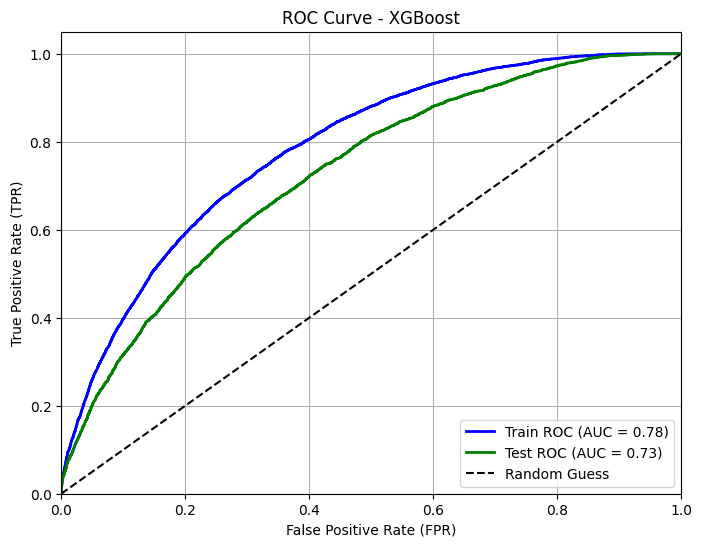

In [ ]:
# ROC Train
fpr_train_xgb, tpr_train_xgb, _ = roc_curve(y_train, y_train_prob)
auc_train_xgb = roc_auc_score(y_train, y_train_prob)

# ROC Test
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test, y_test_prob)
auc_test_xgb = roc_auc_score(y_test, y_test_prob)


Se muestra la grafica lineal de TRAIN y TEST a traves de la curva de ROC

In [ ]:
# Gráfica
plt.figure(figsize=(8,6))
plt.plot(
    fpr_train_xgb,
    tpr_train_xgb,
    color='blue',
    lw=2,
    label=f'Train ROC (AUC = {auc_train_xgb:.2f})'
)

plt.plot(
    fpr_test_xgb,
    tpr_test_xgb,
    color='green',
    lw=2,
    label=f'Test ROC (AUC = {auc_test_xgb:.2f})'
)

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## APLICACION ALGORITMO RANDOM FOREST CON UNDERSAMPLING

Inicializacion de la variable rf_modelo con los hiperparametros de Random Forest

In [ ]:
rf_modelo = RandomForestClassifier(
    n_estimators=800,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

Inicializacion de undersampler para aplicar el balanceo de datos

In [ ]:
undersampler = RandomUnderSampler(
    sampling_strategy=1.0,  # Balancea 1:1
    random_state=42
)

Estable el pipeline con los parametros ya inicializados

In [ ]:
pipeline_rf = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("undersampling", undersampler),
    ("modelo", rf_modelo)
])

Entrenamiento del modelo

In [ ]:
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['PERIODO', 'OPC_INGRESO', 'ANIO_BACHILLERATO', 'ANIOS_POST_BACH',
       'TASA_APR_COLEGIO', 'MAYOR_EDAD', 'MIGRA_UNIVERSIDAD'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['SEXO', 'CIUDAD_COLEGIO', 'PROVINCIA_COLEGIO', 'MUNICIPIO',
       'NACIONALIDAD', 'ESTADO_CIVIL', 'TRABAJO_COLEGIO'],
      dtype='object'))])),
                ('undersampling',
                 RandomUnderSampler(random_state=42, sampling_strategy=1.0)),
                ('modelo',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=800,
                                        n_jobs=-1, random_state=42))])

Se establece los resultados de la prediciones para el train y test

In [ ]:
y_train_pred_rf = pipeline_rf.predict(X_train)
y_train_prob_rf = pipeline_rf.predict_proba(X_train)[:, 1]

y_test_pred_rf = pipeline_rf.predict(X_test)
y_test_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]


Mostramos los resultados del entrenamiento del modelo

In [ ]:
# Matriz de confusión
print(confusion_matrix(y_train, y_train_pred_rf))   # Entrenamiento
print(confusion_matrix(y_test, y_test_pred_rf))     # Prueba

# Resultados de la prediccion con hiperparametros
print(classification_report(y_train, y_train_pred_rf))  # Entrenamiento
print(classification_report(y_test, y_test_pred_rf))    # Prueba

# Accuracy (porcentaje de aciertos)
print("Accuracy TRAIN:", accuracy_score(y_train, y_train_pred_rf))  # Entrenamiento
print("Accuracy TEST:", accuracy_score(y_test, y_test_pred_rf))     # Prueba

# AUC (capacidad de separar las clases)
print("AUC TRAIN:", roc_auc_score(y_train, y_train_prob_rf))  # Entrenamiento
print("AUC TEST:", roc_auc_score(y_test, y_test_prob_rf))     # Prueba


[[14837  9255]
 [ 3179  4647]]
[[7973 5001]
 [1739 2475]]
              precision    recall  f1-score   support

           0       0.82      0.62      0.70     24092
           1       0.33      0.59      0.43      7826

    accuracy                           0.61     31918
   macro avg       0.58      0.60      0.57     31918
weighted avg       0.70      0.61      0.64     31918

              precision    recall  f1-score   support

           0       0.82      0.61      0.70     12974
           1       0.33      0.59      0.42      4214

    accuracy                           0.61     17188
   macro avg       0.58      0.60      0.56     17188
weighted avg       0.70      0.61      0.63     17188

Accuracy TRAIN: 0.6104392505796102
Accuracy TEST: 0.6078659529904584
AUC TRAIN: 0.6539258938571748
AUC TEST: 0.6406422881907072


Se establece varibles nuevas para la evalucion del modelo a a treves de curva de ROC

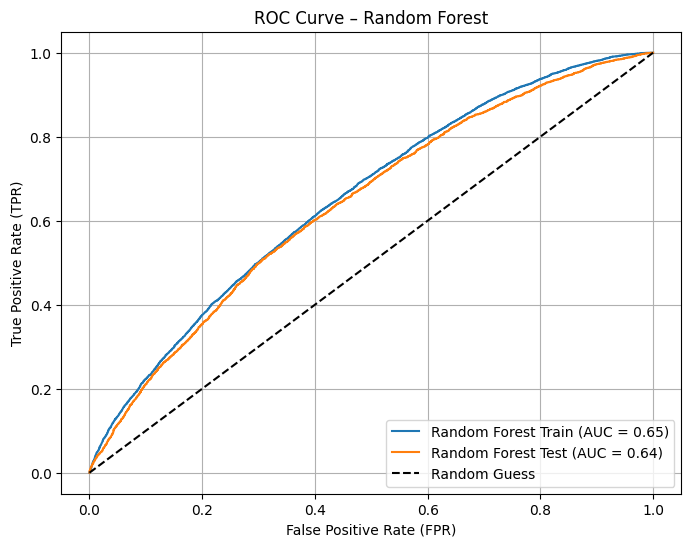

In [ ]:

# Curva ROC TRAIN
fpr_train_rf, tpr_train_rf, _ = roc_curve(y_train, y_train_prob_rf)

# Curva ROC TEST
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_prob_rf)



Se muestra la grafica lineal de TRAIN y TEST a traves de la curva de ROC

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train_rf,
    tpr_train_rf,
    label=f'Random Forest Train (AUC = {roc_auc_score(y_train, y_train_prob_rf):.2f})'
)

plt.plot(
    fpr_test_rf,
    tpr_test_rf,
    label=f'Random Forest Test (AUC = {roc_auc_score(y_test, y_test_prob_rf):.2f})'
)

# Línea base
plt.plot([0,1], [0,1], linestyle='--', color='black', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## APLICACION ALGORITMO REGRESION LOGISTICA BINARIA CON UNDERSAMPLING

Inicializacion de la variable loreg_modelo con los hiperparametros de Random Forest

In [ ]:
logreg_modelo = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=500,
    random_state=42
)

Inicializacion de undersampler para aplicar el balanceo de datos

In [ ]:
undersampler = RandomUnderSampler(
    sampling_strategy=1.0,  # Balancea 1:1
    random_state=42
)

Estable el pipeline con los parametros ya inicializados

In [ ]:
pipeline_logreg = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("undersampling", undersampler),
    ("modelo", logreg_modelo)
])

Entrenamiento del modelo

In [ ]:
pipeline_logreg.fit(X_train, y_train)



Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['PERIODO', 'OPC_INGRESO', 'ANIO_BACHILLERATO', 'ANIOS_POST_BACH',
       'TASA_APR_COLEGIO', 'MAYOR_EDAD', 'MIGRA_UNIVERSIDAD'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['SEXO', 'CIUDAD_COLEGIO', 'PROVINCIA_COLEGIO', 'MUNICIPIO',
       'NACIONALIDAD', 'ESTADO_CIVIL', 'TRABAJO_COLEGIO'],
      dtype='object'))])),
                ('undersampling',
                 RandomUnderSampler(random_state=42, sampling_strategy=1.0)),
                ('modelo',
                 LogisticRegression(max_iter=500, random_state=42,
                                    solver='liblinear'))])

Se establece los resultados de la prediciones para el train y test

In [ ]:
y_train_pred_lr = pipeline_logreg.predict(X_train)
y_train_prob_lr = pipeline_logreg.predict_proba(X_train)[:, 1]

y_test_pred_lr = pipeline_logreg.predict(X_test)
y_test_prob_lr = pipeline_logreg.predict_proba(X_test)[:, 1]


Mostramos los resultados del entrenamiento del modelo

In [ ]:

# Matriz de confusión
print(confusion_matrix(y_train, y_train_pred_lr))   # Entrenamiento
print(confusion_matrix(y_test, y_test_pred_lr))     # Prueba

# Precision, Recall y F1-score
print(classification_report(y_train, y_train_pred_lr))  # Entrenamiento
print(classification_report(y_test, y_test_pred_lr))    # Prueba

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_lr))  # Entrenamiento
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))     # Prueba

# AUC (Área bajo la curva ROC)
print("Train AUC:", roc_auc_score(y_train, y_train_prob_lr))  # Entrenamiento
print("Test AUC:", roc_auc_score(y_test, y_test_prob_lr))     # Prueba


[[15410  8682]
 [ 3154  4672]]
[[8308 4666]
 [1762 2452]]
              precision    recall  f1-score   support

           0       0.83      0.64      0.72     24092
           1       0.35      0.60      0.44      7826

    accuracy                           0.63     31918
   macro avg       0.59      0.62      0.58     31918
weighted avg       0.71      0.63      0.65     31918

              precision    recall  f1-score   support

           0       0.83      0.64      0.72     12974
           1       0.34      0.58      0.43      4214

    accuracy                           0.63     17188
   macro avg       0.58      0.61      0.58     17188
weighted avg       0.71      0.63      0.65     17188

Train Accuracy: 0.6291747603233285
Test Accuracy: 0.6260181521992088
Train AUC: 0.6744513794955609
Test AUC: 0.6622260255606682


Se establece varibles nuevas para la evalucion del modelo a a treves de curva de ROC

In [ ]:
# ROC TRAIN
fpr_train_lr, tpr_train_lr, _ = roc_curve(y_train, y_train_prob_lr)

# ROC TEST
fpr_test_lr, tpr_test_lr, _ = roc_curve(y_test, y_test_prob_lr)

Se muestra la grafica lineal de TRAIN y TEST a traves de la curva de ROC

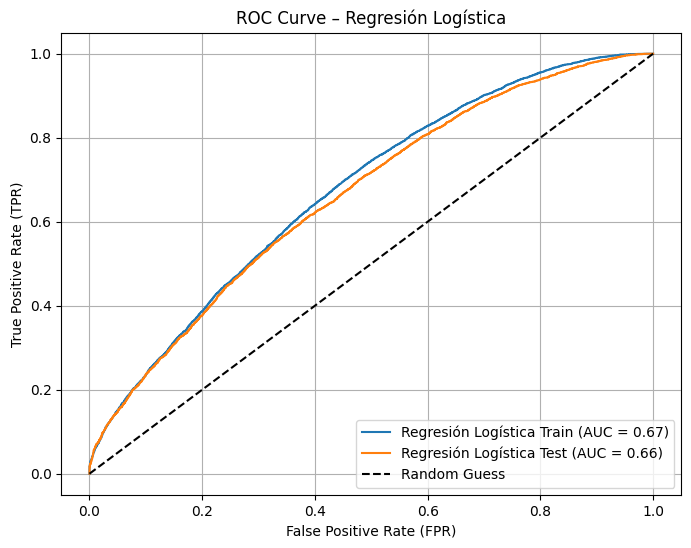

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_train_lr,
    tpr_train_lr,
    label=f'Regresión Logística Train (AUC = {roc_auc_score(y_train, y_train_prob_lr):.2f})'
)

plt.plot(
    fpr_test_lr,
    tpr_test_lr,
    label=f'Regresión Logística Test (AUC = {roc_auc_score(y_test, y_test_prob_lr):.2f})'
)

# Línea base (clasificador aleatorio)
plt.plot([0,1], [0,1], linestyle='--', color='black', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve – Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## COMPARACION DE LOS ALGORITMOS PREDICTIVOS

Se calculan y extraen las métricas de desempeño del modelo para la clase 1

In [ ]:

def extraer_metricas(y_true, y_pred, y_prob):
    reporte = classification_report(y_true, y_pred, output_dict=True)

    precision = reporte['1']['precision']   # clase positiva (aprobado)
    recall = reporte['1']['recall']
    f1 = reporte['1']['f1-score']
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    return [precision, recall, f1, accuracy, auc]


Se guardan en variables la metricas calculadas

In [ ]:
metricas_lr = extraer_metricas(y_test, y_test_pred_lr, y_test_prob_lr)
metricas_rf = extraer_metricas(y_test, y_test_pred_rf, y_test_prob_rf)
metricas_xgb = extraer_metricas(y_test, y_test_pred, y_test_prob)

Funcion para definir las barras en las que se va mostrar los resultados

In [ ]:
def etiquetar_barras(barras):
    for barra in barras:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.01,
            f'{altura:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )


Se graficas las barras con las metricas calculadas

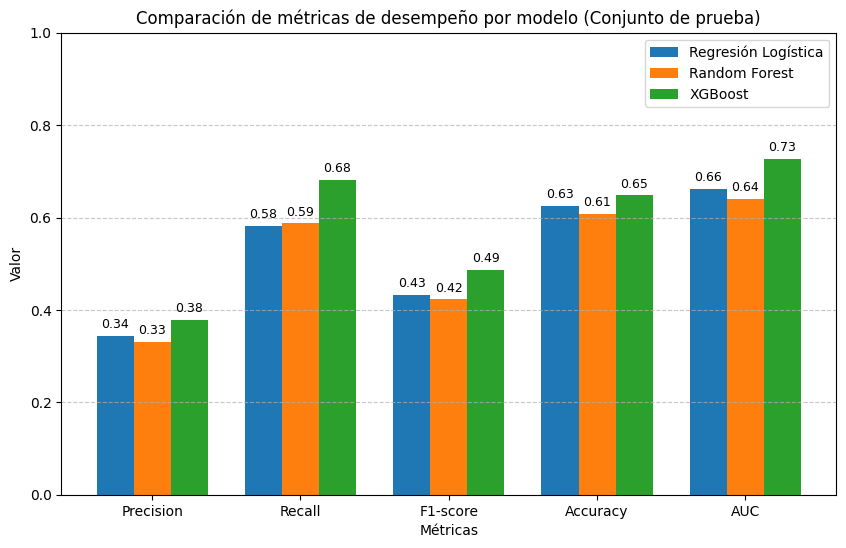

In [ ]:

metricas_nombres = ['Precision', 'Recall', 'F1-score', 'Accuracy', 'AUC']

x = np.arange(len(metricas_nombres))
width = 0.25

plt.figure(figsize=(10,6))

barras_lr = plt.bar(x - width, metricas_lr, width, label='Regresión Logística')
barras_rf = plt.bar(x, metricas_rf, width, label='Random Forest')
barras_xgb = plt.bar(x + width, metricas_xgb, width, label='XGBoost')

# Etiquetas numéricas
etiquetar_barras(barras_lr)
etiquetar_barras(barras_rf)
etiquetar_barras(barras_xgb)

plt.xticks(x, metricas_nombres)
plt.ylim(0, 1)
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.title('Comparación de métricas de desempeño por modelo (Conjunto de prueba)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Al comparar los modelos XGBoost y Random Forest bajo el mismo esquema de preprocesamiento y balanceo con SMOTE, ambos algoritmos muestran desempeños muy similares. XGBoost presenta una ligera ventaja en exactitud global (61.1%), mientras que Random Forest alcanza un AUC marginalmente superior (0.584) y un mejor desempeño en la detección de la clase aprobada, con un mayor recall (0.49) y F1-score (0.37). Dado que el objetivo del estudio es identificar postulantes con probabilidad de aprobar antes del examen, el modelo Random Forest resulta levemente más adecuado.